
  O1
  S1: L*=28.92  a*=-15.02  b*=26.04  R/G=0.7839
  S2: L*=31.85  a*=-13.12  b*=30.46  R/G=0.8706
  S3: L*=36.17  a*=-14.15  b*=38.77  R/G=0.8953
  S4: L*=28.95  a*=-12.09  b*=31.05  R/G=0.8854

  O2
  S1: L*=30.05  a*=-4.21  b*=35.37  R/G=1.1095
  S2: L*=29.21  a*=-5.01  b*=34.04  R/G=1.0843
  S3: L*=26.65  a*=-10.34  b*=27.79  R/G=0.9081
  S4: L*=24.58  a*=-11.10  b*=25.42  R/G=0.8639

  O3
  S1: L*=45.21  a*=12.53  b*=52.79  R/G=1.4895
  S2: L*=54.08  a*=11.10  b*=59.68  R/G=1.4144
  S3: L*=58.28  a*=9.24  b*=62.99  R/G=1.3665
  S4: L*=56.03  a*=9.41  b*=61.03  R/G=1.3757


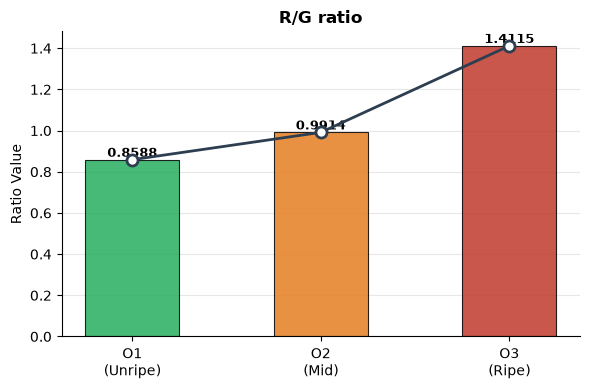

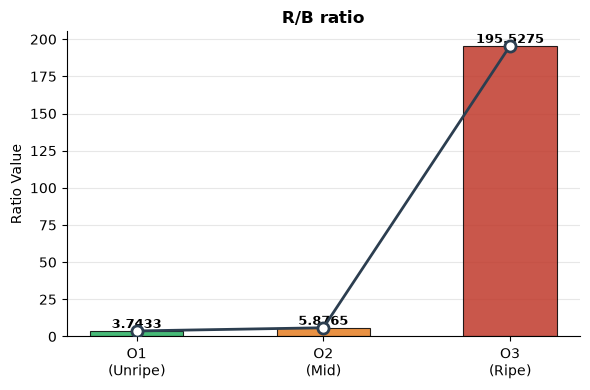


===== CCI VALUES =====
O1: CCI = -1.3676
O2: CCI = -0.9053
O3: CCI = 0.3348


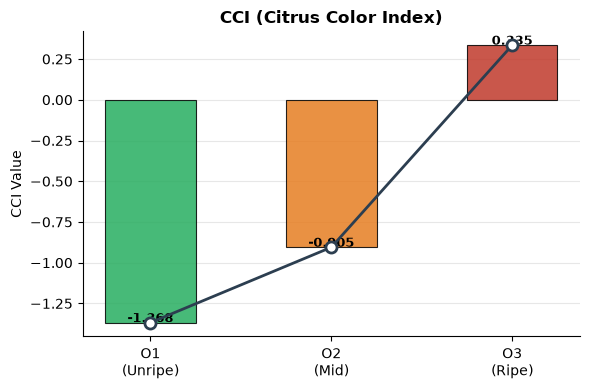

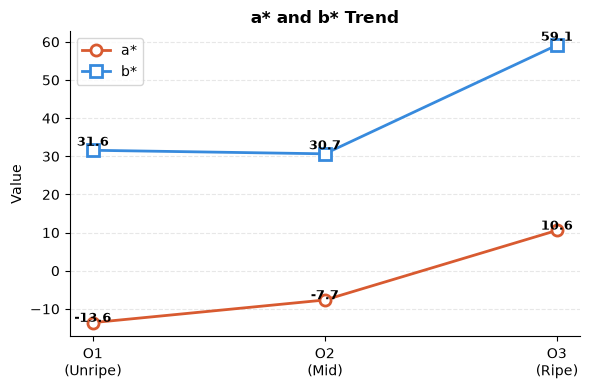

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches
from skimage import color

# ============================================================
# CONFIGURATION
# ============================================================

oranges = {
    "O1": {
        "files": [
            r"Data\Orange\ImagesSample\O1_S1.jpeg",
            r"Data\Orange\ImagesSample\O1_S2.jpeg",
            r"Data\Orange\ImagesSample\O1_S3.jpeg",
            r"Data\Orange\ImagesSample\O1_S4.jpeg",
        ],
        "circles": [(1553,2413,100),(1630,2523,100),(1466,2263,100),(1540,2320,100)],
        "color": "#D85A30",
        "label": "O1 (Unripe)",
    },
    "O2": {
        "files": [
            r"Data\Orange\ImagesSample\O2_S1.jpeg",
            r"Data\Orange\ImagesSample\O2_S2.jpeg",
            r"Data\Orange\ImagesSample\O2_S3.jpeg",
            r"Data\Orange\ImagesSample\O2_S4.jpeg",
        ],
        "circles": [(1450,2453,100),(1686,2440,100),(1603,2460,100),(1570,2396,100)],
        "color": "#EF9F27",
        "label": "O2 (Mid-ripe)",
    },
    "O3": {
        "files": [
            r"Data\Orange\ImagesSample\O3_S1.jpeg",
            r"Data\Orange\ImagesSample\O3_S2.jpeg",
            r"Data\Orange\ImagesSample\O3_S3.jpeg",
            r"Data\Orange\ImagesSample\O3_S4.jpeg",
        ],
        "circles": [(1906,2416,100),(1773,2083,100),(1756,2016,100),(1783,1946,100)],
        "color": "#639922",
        "label": "O3 (Ripe)",
    },
}





# ============================================================
# FEATURE EXTRACTION
# ============================================================
# RGB wavelength axis (approximate mapping R=700nm, G=550nm, B=450nm)
# For camera RGB we use proxy bands: B=450, G=550, R=700
WAVELENGTHS = np.array([450, 550, 700])   # B, G, R order
summary = {}
for orange_id, data in oranges.items():
    print(f"\n{'='*50}\n  {orange_id}\n{'='*50}")

    L_list, a_list, b_list = [], [], []
    rg_list, rb_list, nd_list = [], [], []
    all_pix_lab = []
    spectra_per_sample = []   # each entry: mean [B, G, R] for that sample

    for idx, (file, circle) in enumerate(zip(data["files"], data["circles"])):
        img_bgr = cv2.imread(file)
        if img_bgr is None:
            print(f"  [ERROR] {file}")
            continue       
        
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb_norm = img_rgb.astype(np.float32) / 255.0
        img_lab = color.rgb2lab(img_rgb_norm)

        x, y, r = circle
        mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
        cv2.circle(mask, (x, y), r, 255, -1)

        # LAB
        pix_lab = img_lab[mask == 255].astype(np.float32)
        L_vals  = pix_lab[:, 0]
        a_vals  = pix_lab[:, 1] 
        b_vals  = pix_lab[:, 2]
        L_list.append(np.mean(L_vals))
        a_list.append(np.mean(a_vals))
        b_list.append(np.mean(b_vals))
        all_pix_lab.append(np.stack([L_vals, a_vals, b_vals], axis=1))

        # RGB
        pix_rgb = img_rgb[mask == 255].astype(np.float32)
        R = np.mean(pix_rgb[:, 0])
        G = np.mean(pix_rgb[:, 1])
        B = np.mean(pix_rgb[:, 2])
        rg_list.append(R / G if G else 0)
        rb_list.append(R / B if B else 0)
        nd_list.append((R - G) / (R + G) if (R + G) else 0)

        # Spectrum proxy: [B, G, R] mean intensity
        spectra_per_sample.append(np.array([B, G, R]))

        print(f"  S{idx+1}: L*={L_list[-1]:.2f}  a*={a_list[-1]:.2f}  "
              f"b*={b_list[-1]:.2f}  R/G={rg_list[-1]:.4f}")

    spectra_arr = np.array(spectra_per_sample)   # shape (4, 3)
    mean_spectrum = spectra_arr.mean(axis=0)

    summary[orange_id] = {
        "color":          data["color"],
        "label":          data["label"],
        "L":              np.array(L_list),
        "a":              np.array(a_list),
        "b":              np.array(b_list),
        "rg":             np.array(rg_list),
        "rb":             np.array(rb_list),
        "nd":             np.array(nd_list),
        "pix_lab":        np.vstack(all_pix_lab),
        "spectra":        spectra_arr,       # (4, 3)  — B G R per sample
        "mean_spectrum":  mean_spectrum,     # (3,)
    }

oids    = list(summary.keys())
samples = ["S1", "S2", "S3", "S4"]

# ============================================================
# FINAL PLOTS 
# ============================================================

bar_colors  = ['#27ae60', '#e67e22', '#c0392b']
trend_color = '#2c3e50'

x = np.array([1, 2, 3])
x_lbls = ['O1\n(Unripe)', 'O2\n(Mid)', 'O3\n(Ripe)']

plt.figure(figsize=(6,4))
ax = plt.gca()

vals = [np.mean(summary[o]["rg"]) for o in oids]

bars = ax.bar(x, vals, color=bar_colors, width=0.5,
              alpha=0.85, edgecolor='black', linewidth=0.8)

ax.plot(x, vals, 'o-', color=trend_color,
        linewidth=2, markersize=8,
        markerfacecolor='white', markeredgewidth=2, zorder=5)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01 * max(vals),
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title("R/G ratio", fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_lbls)
ax.set_ylabel("Ratio Value")

ax.set_axisbelow(True)
ax.grid(True, alpha=0.3, axis='y')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("RG_plot.png", dpi=600, bbox_inches='tight')
plt.show()


# ============================================================
# R/B 
# ============================================================

plt.figure(figsize=(6,4))
ax = plt.gca()

vals = [np.mean(summary[o]["rb"]) for o in oids]

bars = ax.bar(x, vals, color=bar_colors, width=0.5,
              alpha=0.85, edgecolor='black', linewidth=0.8)

ax.plot(x, vals, 'o-', color=trend_color,
        linewidth=2, markersize=8,
        markerfacecolor='white', markeredgewidth=2, zorder=5)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01 * max(vals),
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title("R/B ratio", fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_lbls)
ax.set_ylabel("Ratio Value")

ax.set_axisbelow(True)
ax.grid(True, alpha=0.3, axis='y')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("RB_plot.png", dpi=600, bbox_inches='tight')
plt.show()
# ============================================================
# CCI (Citrus Color Index) — TRUE CIELAB
# ============================================================

cci_vals = []

print("\n===== CCI VALUES =====")
for oid in oids:
    L = np.mean(summary[oid]["L"])
    a = np.mean(summary[oid]["a"])
    b = np.mean(summary[oid]["b"])

    cci = (100 * a) / (L * b) if (L * b) != 0 else 0
    cci_vals.append(cci)

    print(f"{oid}: CCI = {cci:.4f}")

# ============================================================
# CCI PLOT (Hunter Lab / True CIELAB)
# ============================================================

plt.figure(figsize=(6,4))
ax = plt.gca()

vals = cci_vals

bars = ax.bar(x, vals, color=bar_colors, width=0.5,
              alpha=0.85, edgecolor='black', linewidth=0.8)

ax.plot(x, vals, 'o-', color=trend_color,
        linewidth=2, markersize=8,
        markerfacecolor='white', markeredgewidth=2, zorder=5)

for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01 * max(vals),
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title("CCI (Citrus Color Index)", fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_lbls)
ax.set_ylabel("CCI Value")

ax.set_axisbelow(True)
ax.grid(True, alpha=0.3, axis='y')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("CCI_plot.png", dpi=600, bbox_inches='tight')
plt.show()

# ============================================================
# a* and b* MEAN TREND PLOT
# ============================================================
# ============================================================
# a* and b* TREND 
# ============================================================

plt.figure(figsize=(6,4))
ax = plt.gca()

# ---- Data ----
a_vals = [np.mean(summary[o]["a"]) for o in oids]
b_vals = [np.mean(summary[o]["b"]) for o in oids]

x = np.array([1, 2, 3])
x_lbls = ['O1\n(Unripe)', 'O2\n(Mid)', 'O3\n(Ripe)']

# ---- Plot a* ----
ax.plot(x, a_vals, 'o-', color='#D85A30',
        linewidth=2, markersize=8,
        markerfacecolor='white', markeredgewidth=2,
        label='a*')

# ---- Plot b* ----
ax.plot(x, b_vals, 's-', color='#378ADD',
        linewidth=2, markersize=8,
        markerfacecolor='white', markeredgewidth=2,
        label='b*')

# ---- Value labels ----
for i, v in enumerate(a_vals):
    ax.text(x[i], v + 0.02 * max(a_vals),
            f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

for i, v in enumerate(b_vals):
    ax.text(x[i], v + 0.02 * max(b_vals),
            f'{v:.1f}', ha='center', fontsize=9, fontweight='bold')

# ---- Labels ----
ax.set_title("a* and b* Trend", fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(x_lbls)
ax.set_ylabel("Value")

# ---- Grid (horizontal only, behind) ----
ax.set_axisbelow(True)
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.grid(False, axis='x')

# ---- Clean axes ----
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend()

plt.tight_layout()
plt.savefig("ab_trend.png", dpi=600, bbox_inches='tight')
plt.show()
